# Exploratory Data Analysis — NASA C-MAPSS FD001

Goal: understand the data before modeling. What do sensors look like? Which ones degrade? How long do engines live?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pdm.config import ALL_COLS, SENSOR_COLS, DROP_SENSORS, FEATURE_SENSORS
from pdm.data.load import load_raw

train, test, rul = load_raw("FD001")
print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")
print(f"RUL labels:  {len(rul)}")

Train shape: (20631, 26)
Test shape:  (13096, 26)
RUL labels:  100



## 1. Engine lifetimes

How long do engines survive? This tells us the range of RUL values our model needs to predict.

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


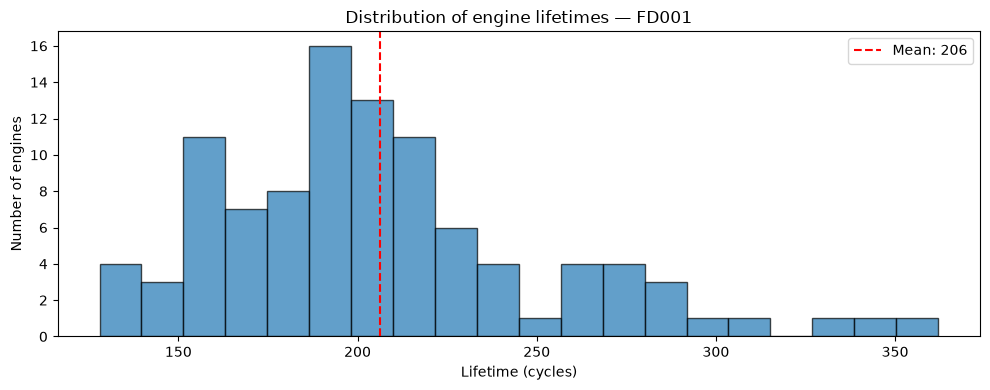

In [2]:
lifetimes = train.groupby("unit")["cycle"].max()
print(lifetimes.describe())

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(lifetimes, bins=20, edgecolor="black", alpha=0.7)
ax.set_xlabel("Lifetime (cycles)")
ax.set_ylabel("Number of engines")
ax.set_title("Distribution of engine lifetimes — FD001")
ax.axvline(lifetimes.mean(), color="red", linestyle="--", label=f"Mean: {lifetimes.mean():.0f}")
plt.legend()
plt.tight_layout()
plt.show()

## 2. Sensor behavior over time

Plot a few engines to see how sensors change as the engine degrades. Pick engines with short, medium, and long lifetimes.

In [3]:
# Pick 3 engines: short, medium, long life
units_to_plot = [
    lifetimes.idxmin(),  # shortest life
    lifetimes.sub(lifetimes.median()).abs().idxmin(),  # closest to median
    lifetimes.idxmax(),  # longest life
]
print(f"Plotting engines: {units_to_plot}")
print(f"Their lifetimes:  {[lifetimes[u] for u in units_to_plot]}")

Plotting engines: [np.int64(39), np.int64(26), np.int64(69)]
Their lifetimes:  [np.int64(128), np.int64(199), np.int64(362)]


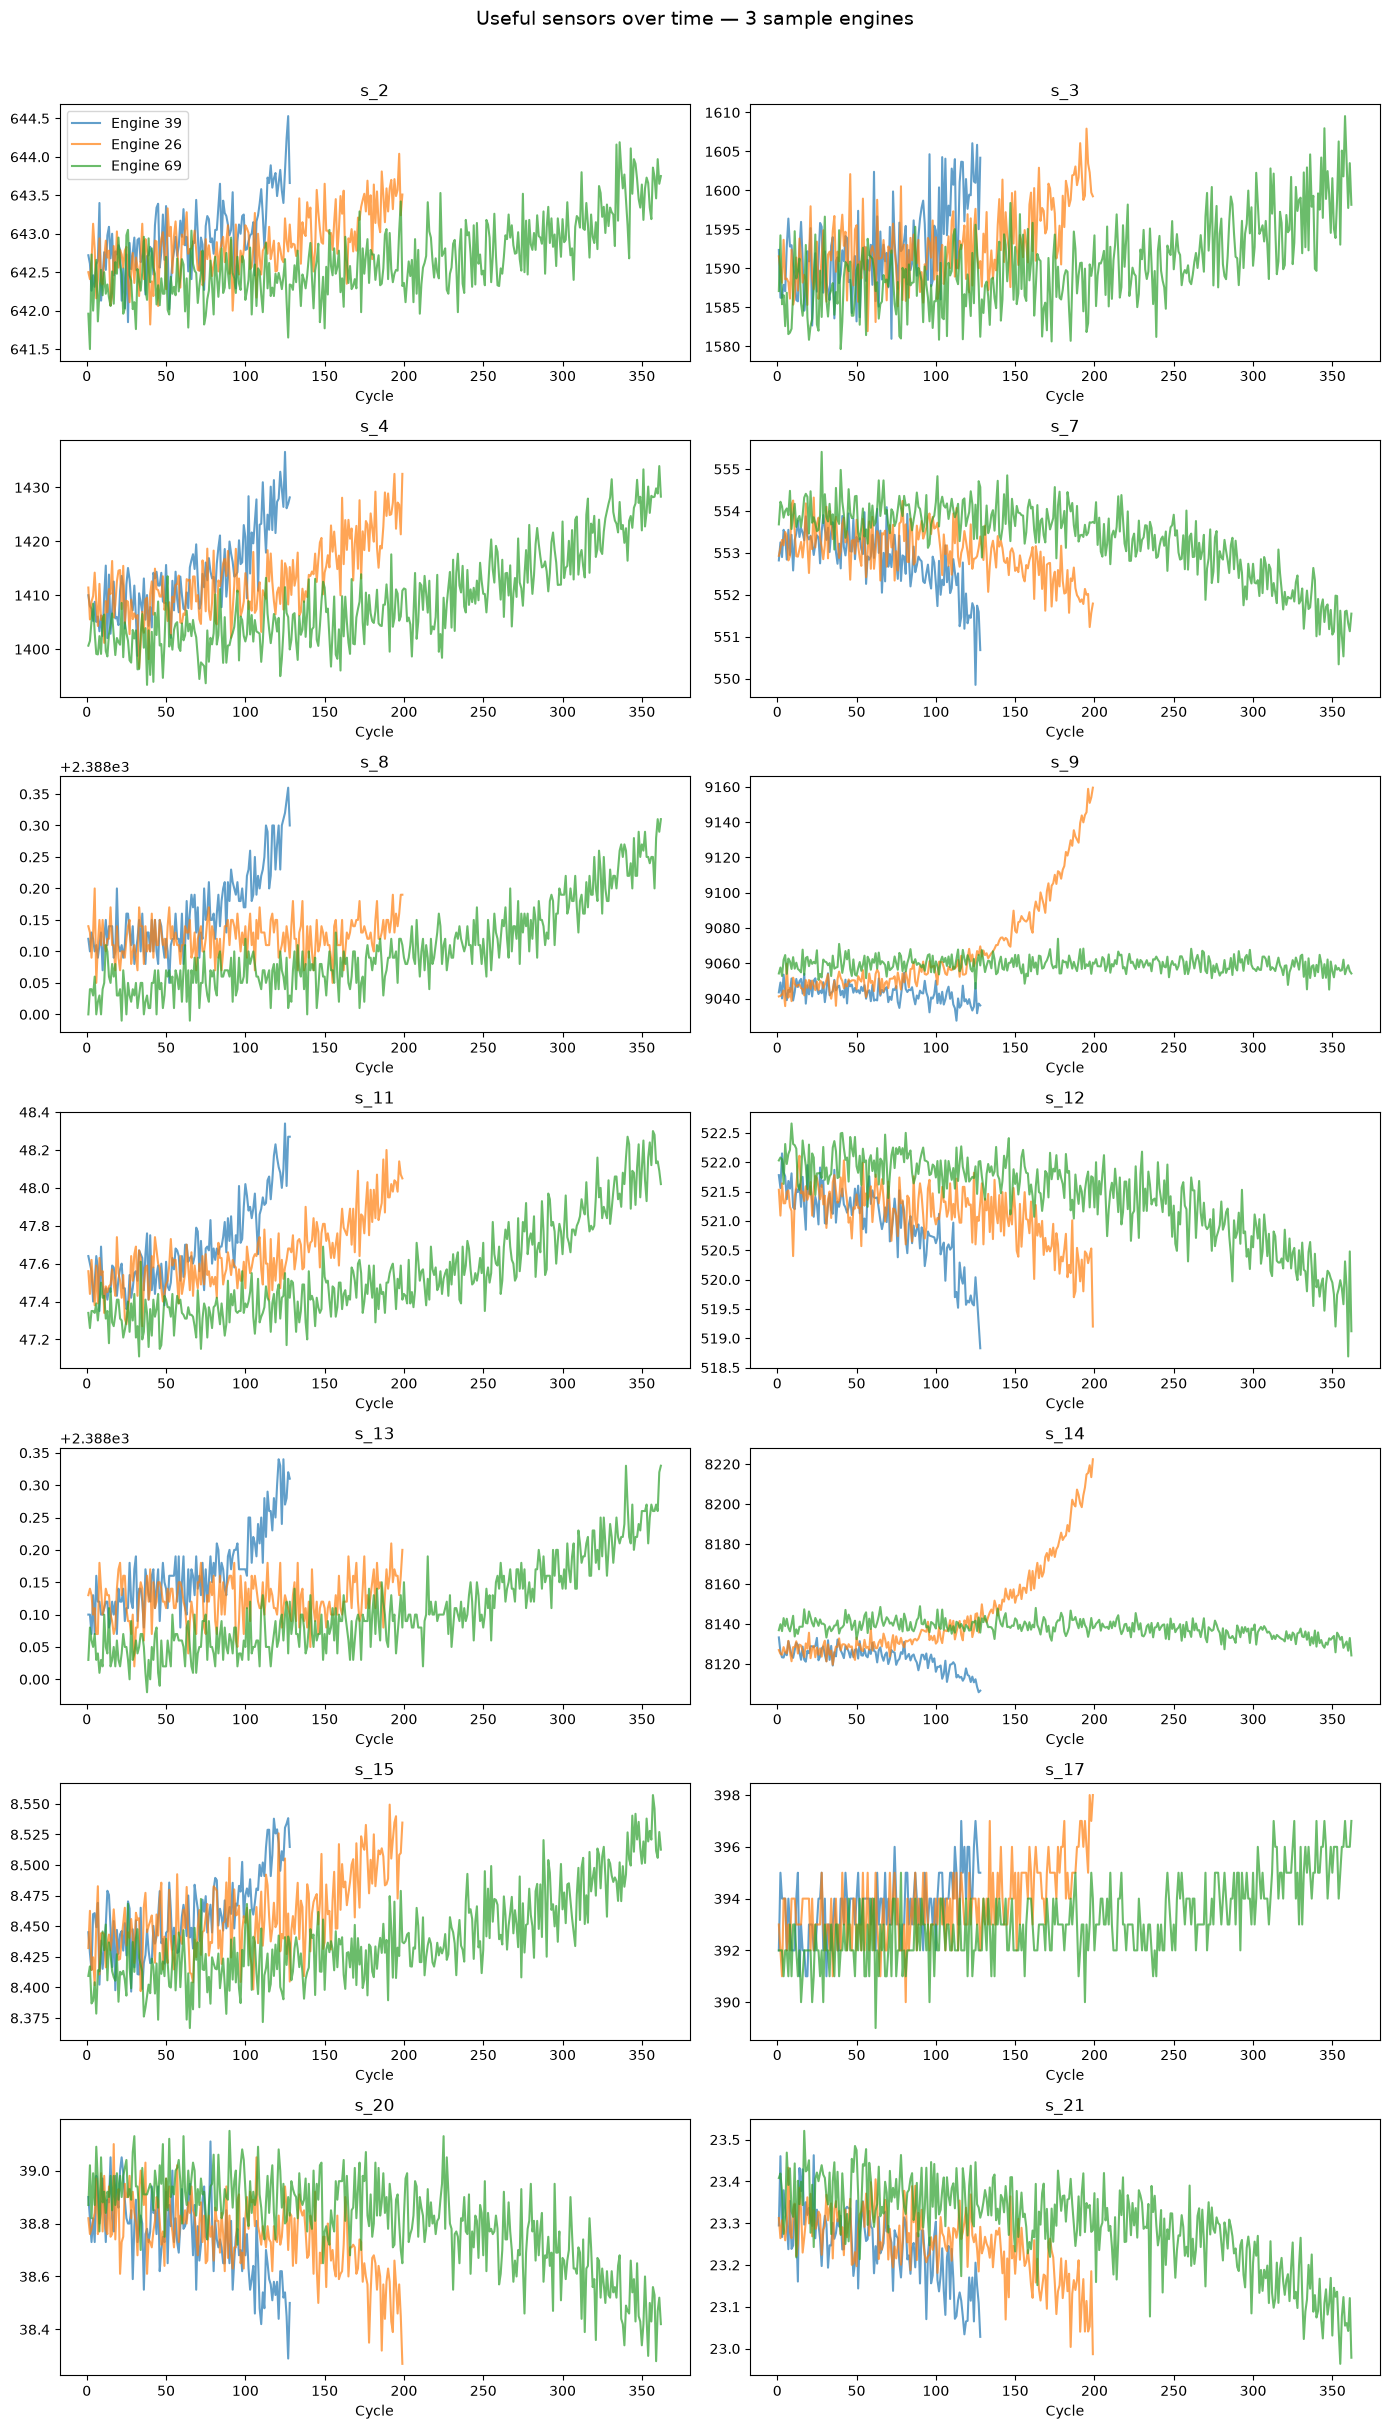

In [4]:
# Plot the 14 useful sensors for these 3 engines
fig, axes = plt.subplots(7, 2, figsize=(14, 24))
axes = axes.flatten()

for i, sensor in enumerate(FEATURE_SENSORS):
    ax = axes[i]
    for unit in units_to_plot:
        engine = train[train["unit"] == unit]
        ax.plot(engine["cycle"], engine[sensor], label=f"Engine {unit}", alpha=0.7)
    ax.set_title(sensor)
    ax.set_xlabel("Cycle")
    if i == 0:
        ax.legend()

plt.suptitle("Useful sensors over time — 3 sample engines", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

## 3. Dropped sensors — confirming they are flat

Let's verify that the sensors we decided to drop truly carry no information.

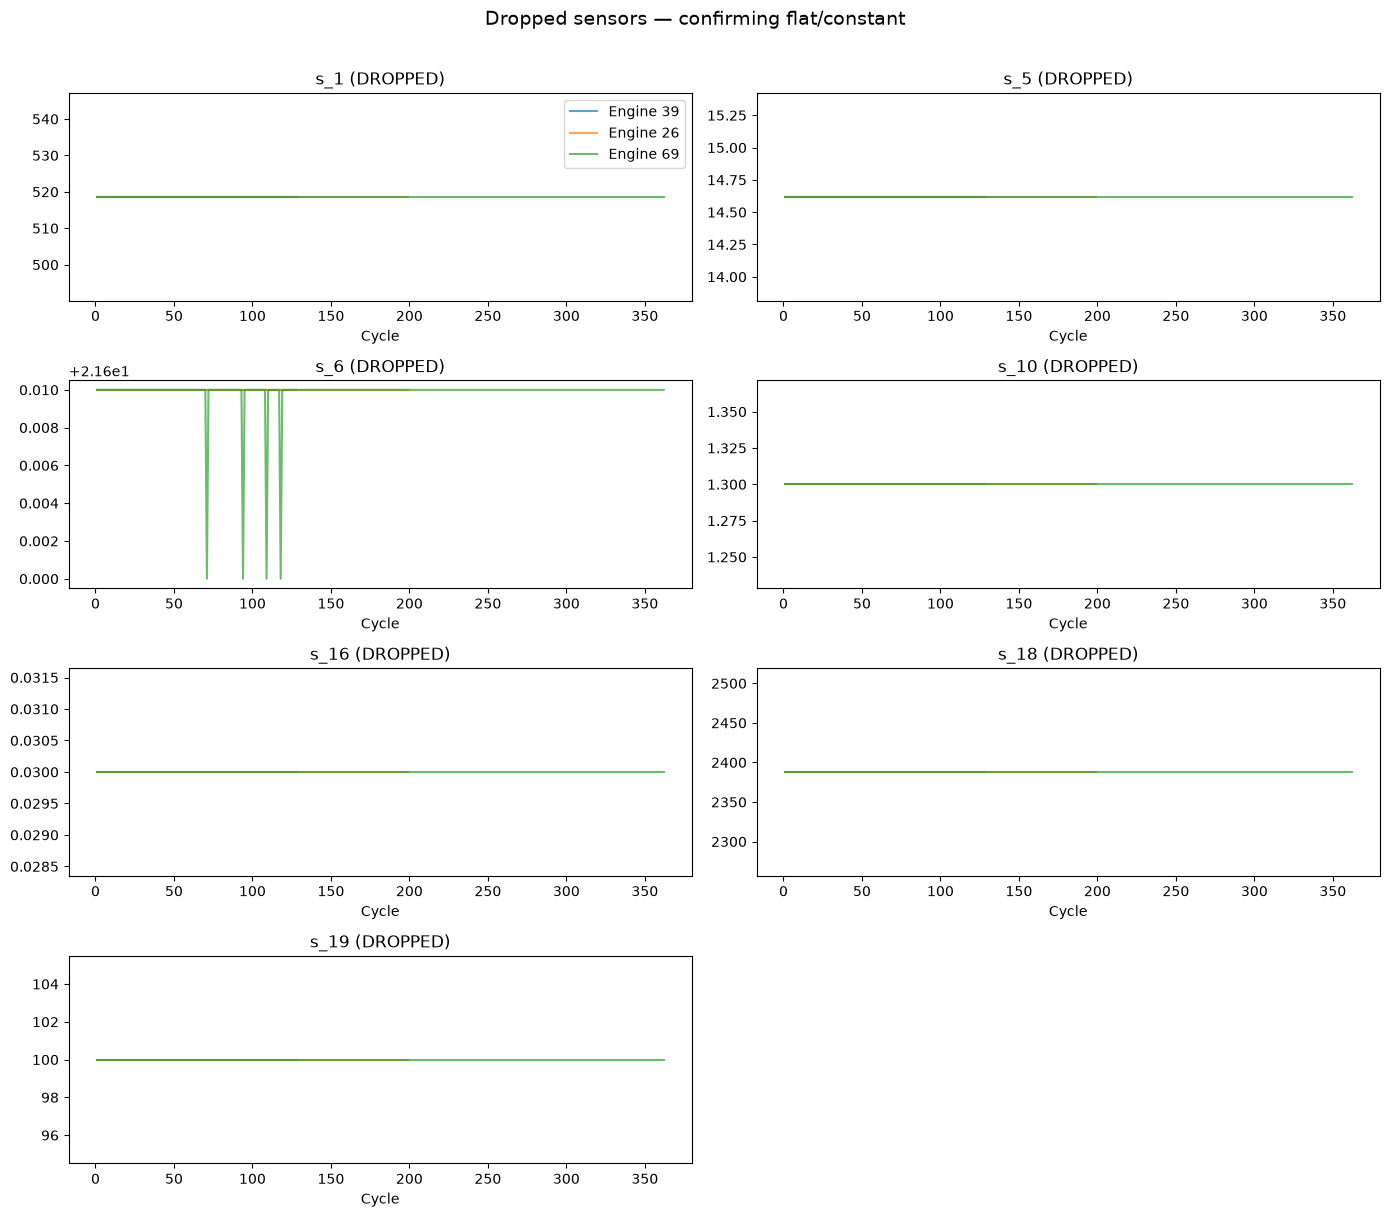

In [5]:
fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()

for i, sensor in enumerate(DROP_SENSORS):
    ax = axes[i]
    for unit in units_to_plot:
        engine = train[train["unit"] == unit]
        ax.plot(engine["cycle"], engine[sensor], label=f"Engine {unit}", alpha=0.7)
    ax.set_title(f"{sensor} (DROPPED)")
    ax.set_xlabel("Cycle")
    if i == 0:
        ax.legend()

# hide the unused 8th subplot
axes[7].set_visible(False)

plt.suptitle("Dropped sensors — confirming flat/constant", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

## 4. Sensor correlation with degradation

Which sensors correlate most strongly with cycle number? High correlation = strong degradation signal.

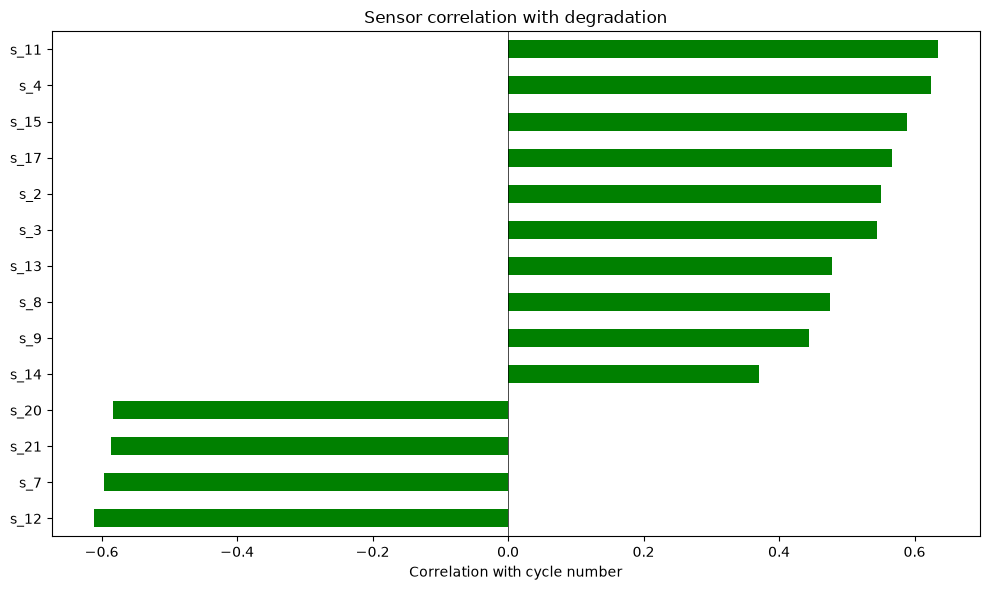


Strongest degradation signals (|corr| > 0.3):
s_12   -0.611354
s_7    -0.595914
s_21   -0.585923
s_20   -0.583597
s_14    0.370324
s_9     0.443999
s_8     0.475977
s_13    0.477523
s_3     0.543947
s_2     0.549898
s_17    0.566995
s_15    0.588676
s_4     0.624577
s_11    0.634385
Name: cycle, dtype: float64


In [6]:
corr_with_cycle = train[FEATURE_SENSORS + ["cycle"]].corr()["cycle"].drop("cycle").sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["green" if abs(v) > 0.3 else "gray" for v in corr_with_cycle]
corr_with_cycle.plot.barh(ax=ax, color=colors)
ax.set_xlabel("Correlation with cycle number")
ax.set_title("Sensor correlation with degradation")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

print("\nStrongest degradation signals (|corr| > 0.3):")
print(corr_with_cycle[corr_with_cycle.abs() > 0.3])

## 5. Test set — what does the prediction task look like?

Each test engine is truncated at a random point. The RUL file tells us the true remaining life at that cutoff.

In [7]:
test_lifetimes = test.groupby("unit")["cycle"].max()

print(f"Test engines: {len(test_lifetimes)}")
print(f"\nCycles observed (truncated):")
print(test_lifetimes.describe())
print(f"\nTrue RUL at cutoff:")
print(rul.describe())

Test engines: 100

Cycles observed (truncated):
count    100.000000
mean     130.960000
std       53.593479
min       31.000000
25%       88.750000
50%      133.500000
75%      164.250000
max      303.000000
Name: cycle, dtype: float64

True RUL at cutoff:
count    100.00000
mean      75.52000
std       41.76497
min        7.00000
25%       32.75000
50%       86.00000
75%      112.25000
max      145.00000
Name: 0, dtype: float64
